# Deep Learning — Satellite Spectra Classification
**EDHEC Business School — Deep Learning Course**

## Problem Statement

This project works with a dataset from a CNES (French Space Agency) challenge on automatic analysis of satellite spectra.

The goal is to build a **multi-input / multi-output deep learning model** that predicts two binary labels from spectral and auxiliary data:
- whether the observed region contains water
- whether the observed region is cloud-covered

**Inputs:**
- `spectra.npy`: main spectral measurements (high-dimensional numerical data)
- `auxiliary.csv`: additional tabular information for each spectrum
- `targets.csv`: target variables for each spectrum



# 1 - Loading, Initial Exploration

In [1]:
# Librairies for part 1 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1.1 Data loading

Code below loads the **training data only** as NumPy arrays and pandas
DataFrames.  
I will then perform preprocessing and build the 
requested multi-input / multi-output model.

In [2]:

# Main spectral data (NumPy array)
spectra_path = "spectra.npy"
X_spectra = np.load(spectra_path)

# Auxiliary tabular data (pandas DataFrame)
auxiliary_path = "auxiliary.csv"
X_aux = pd.read_csv(auxiliary_path)

# Targets (pandas DataFrame)
targets_path = "targets.csv"
y = pd.read_csv(targets_path)

print("Spectra shape:", X_spectra.shape)
print("Auxiliary shape:", X_aux.shape)
print("Targets shape:", y.shape)

Spectra shape: (3000, 52, 3)
Auxiliary shape: (3000, 5)
Targets shape: (3000, 3)


## 1.2 Data inspection

In [3]:
# X_aux

print(f"\nX_aux shape: {X_aux.shape}")

print("\nX_aux overview:")
X_aux.head()


X_aux shape: (3000, 5)

X_aux overview:


,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,semi_major_axis_m
0,1.570836e+30,494402820.0,5033.0,1.262481e+26,2.277510e+10
1,1.710024e+30,591890700.0,5320.0,3.959436e+25,1.217744e+10
2,1.153272e+30,382988100.0,3985.0,8.958000e+25,1.057672e+10
3,3.777960e+29,146231820.0,2988.0,3.810136e+25,1.431672e+10
4,1.371996e+30,445658880.0,4925.0,8.360800e+25,1.795200e+10


In [4]:
X_aux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   star_mass_kg       3000 non-null   float64
 1   star_radius_m      3000 non-null   float64
 2   star_temperature   3000 non-null   float64
 3   planet_mass_kg     3000 non-null   float64
 4   semi_major_axis_m  3000 non-null   float64
dtypes: float64(5)
memory usage: 117.3 KB


In [5]:
# X_spectra

print(f"\nX_spectra shape: {X_spectra.shape}")
len(X_spectra),len

print("\nX_spectra[0][:10] overview:")
X_spectra[0][:10]




X_spectra shape: (3000, 52, 3)

X_spectra[0][:10] overview:


array([[7.27555920e+00, 9.70204688e-04, 1.52272346e-06],
       [6.81373911e+00, 9.70978975e-04, 1.36892043e-06],
       [6.38123330e+00, 9.69837948e-04, 1.18543536e-06],
       [5.97618103e+00, 9.69689623e-04, 1.03240450e-06],
       [5.59683967e+00, 9.71837966e-04, 9.03564401e-07],
       [5.24157722e+00, 9.70432837e-04, 7.94207982e-07],
       [4.90886524e+00, 9.70721674e-04, 7.00733031e-07],
       [4.59727234e+00, 9.69475133e-04, 6.20338975e-07],
       [4.30545796e+00, 9.69583493e-04, 5.50818120e-07],
       [4.03216667e+00, 9.70652762e-04, 5.28171279e-07]])

In [6]:
def spectra_info(X):
    N, F, C = X.shape
    print(f"NumPy array: shape={X.shape}, dtype={X.dtype}, nbytes={X.nbytes}\n")
    print("Columns:")
    
    for f in range(F):
        for c in range(C):
            col = X[:, f, c]
            nn = np.count_nonzero(~np.isnan(col))
            print(f"feature {f:02d}, channel {c+1}:" f"  non-null={nn}  ",
                  f"dtype={col.dtype}")

# usage
spectra_info(X_spectra)

NumPy array: shape=(3000, 52, 3), dtype=float64, nbytes=3744000

Columns:
feature 00, channel 1:  non-null=3000   dtype=float64
feature 00, channel 2:  non-null=3000   dtype=float64
feature 00, channel 3:  non-null=3000   dtype=float64
feature 01, channel 1:  non-null=3000   dtype=float64
feature 01, channel 2:  non-null=3000   dtype=float64
feature 01, channel 3:  non-null=3000   dtype=float64
feature 02, channel 1:  non-null=3000   dtype=float64
feature 02, channel 2:  non-null=3000   dtype=float64
feature 02, channel 3:  non-null=3000   dtype=float64
feature 03, channel 1:  non-null=3000   dtype=float64
feature 03, channel 2:  non-null=3000   dtype=float64
feature 03, channel 3:  non-null=3000   dtype=float64
feature 04, channel 1:  non-null=3000   dtype=float64
feature 04, channel 2:  non-null=3000   dtype=float64
feature 04, channel 3:  non-null=3000   dtype=float64
feature 05, channel 1:  non-null=3000   dtype=float64
feature 05, channel 2:  non-null=3000   dtype=float64
feature 

In [7]:
def spectra_info_df(X):
    N, F, C = X.shape
    rows = []

    for f in range(F):
        for c in range(C):
            col = X[:, f, c]
            rows.append({
                "feature": f,
                "channel": c,
                "non_null": np.count_nonzero(~np.isnan(col)),
                "nulls": np.isnan(col).sum(),
                "dtype": col.dtype
            })
    
    return pd.DataFrame(rows)

# usage
info_table = spectra_info_df(X_spectra)
total_nulls = info_table["nulls"].sum()
all_int64 = (info_table["dtype"].eq(np.float64).all())
print(f"Total nulls: ", total_nulls)
print(f"All features are float64: ", all_int64)
info_table

Total nulls:  0
All features are float64:  True


,feature,channel,non_null,nulls,dtype
0,0,0,3000,0,float64
1,0,1,3000,0,float64
2,0,2,3000,0,float64
3,1,0,3000,0,float64
4,1,1,3000,0,float64
...,...,...,...,...,...
151,50,1,3000,0,float64
152,50,2,3000,0,float64
153,51,0,3000,0,float64
154,51,1,3000,0,float64


In [8]:
# y

print(f"\ny shape {y.shape}")

print("\ny overview:")
y.head()


y shape (3000, 3)

y overview:


,id,water,cloud
0,0,0,1
1,1,1,0
2,2,0,0
3,3,1,1
4,4,1,1


In [9]:
print('\n Targets balance:')
print(f"  water: {y['water'].mean():.0%} positive")
print(f"  cloud: {y['cloud'].mean():.0%} positive")


 Targets balance:
  water: 50% positive
  cloud: 50% positive


In [10]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      3000 non-null   int64
 1   water   3000 non-null   int64
 2   cloud   3000 non-null   int64
dtypes: int64(3)
memory usage: 70.4 KB


At this stage, here is the data summary of the data:
- training data has 3000 rows.
- for each row, X_aux has 5 features
- for each row, X_spectra has 52 features on 3 channels
- all features are numerical (so no encoding task required)
- there are no (0) nulls
- the 2 outputs are 'water' and 'cloud'
- both outputs are binary (so there are 2 binary classification tasks)
- both outputs are class-balanced (this wil matter in metric choice)

# 2 - Preprocessing

In [11]:
# Librairies for part 2

from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler

## 2.1 Train / Validation Split

I want to keep the class balances of 50% in this split. For this in scikit-learn I use pairing.

In [12]:
# 80/20% split

# stratify using the pair (water, cloud)
strat = y[['water','cloud']].astype(str).agg('_'.join, axis=1)

idx_train, idx_val = train_test_split(
    np.arange(len(y)),
    test_size=0.2,
    random_state=42,
    stratify=strat
)

# Auxiliary data (df)
X_aux_train = X_aux.iloc[idx_train].copy()
X_aux_val   = X_aux.iloc[idx_val].copy()
# Labels (Pandas DataFrame)
y_train = y.iloc[idx_train].copy()
y_val   = y.iloc[idx_val].copy()
# Spectra arrays (numpy array) (nb 3d tensor but the first dimensions is rows)
X_spectra_train = X_spectra[idx_train]
X_spectra_val   = X_spectra[idx_val]


print(f'Training split: {len(idx_train)} | Val split: {len(idx_val)}')
print('\nClass balance check:')
for name, idx in [('Train', idx_train), ('Val', idx_val)]:
    w = y['water'].iloc[idx].mean()
    c = y['cloud'].iloc[idx].mean()
    print(f'  {name:6s}  water={w:.3f}  cloud={c:.3f}')

Training split: 2400 | Val split: 600

Class balance check:
  Train   water=0.500  cloud=0.500
  Val     water=0.500  cloud=0.500


Note that the split is done before doing any feature engineering, to prevent any leakage from validation data if I use distribution-related metrics for the feature engineering, or even to avoid cheating on plots to find interesting row-wise computations.

## 2.2 From EDA to Feature Engineering

### 2.2.A. X_aux: Auxiliary features

During exploration I looked at the distributions the five auxiliary physical features. I plotted the distributions for the training data.

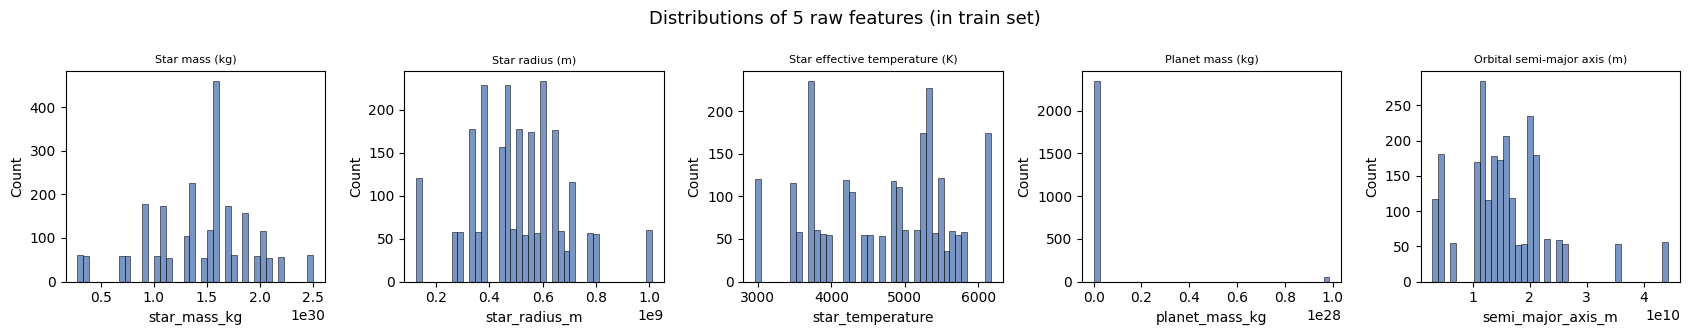

In [13]:
# Distributions of 5 raw features (in train set): star_mass_kg,	star_radius_m,	star_temperature,	planet_mass_kg,	semi_major_axis_m

raw_features = [
    ('star_mass_kg',          'Star mass (kg)'),
    ('star_radius_m',         'Star radius (m)'),
    ('star_temperature',      'Star effective temperature (K)'),
    ('planet_mass_kg',        'Planet mass (kg)'),
    ('semi_major_axis_m',     'Orbital semi-major axis (m)')
]


fig, axes = plt.subplots(1, 5, figsize=(17, 3))
for ax, (feat, title) in zip(axes, raw_features):
    sns.histplot(X_aux_train[feat], bins=40, ax=ax, color=sns.color_palette("deep")[0])
    ax.set_title(title, fontsize=8)
plt.tight_layout()
fig.suptitle('Distributions of 5 raw features (in train set)',fontsize=13, y=1.1)
plt.show()

When I first built the model, feeding it the raw data directly (with scaling), it predicted at around 50% accuracy, which is no better than random.  
Even with hyperparamter tuning and tweaking the architecture one could barely get it to above 55%.  

As the data itself does not suffer from encoding issues, nor mixed data type, and scaling returned no issue,  
I figured out that preprocessing the feature was not the issue, but that the feature itself were not giving enough signal.  

When I looked at feature engineering, after extensive research on the websites about, and (much) thanks to a physics background (prepa PC),  
after trial & error, I came up with a list of new features derived from the native features of X_aux.




Starting from the 5 raw columns: `star_mass_kg`, `star_radius_m`, `star_temperature`, `planet_mass_kg`, `semi_major_axis_m`.

I researched standard formulas used in exoplanet atmospheric science and found the following:

| Engineered feature | Formula | What it represents (that's more for personal culture G..)|
|---|---|---|
| `flux_received` | $T_{star}^4 / d^2$ | How much stellar radiation hits the planet — the primary driver of surface temperature and water vapour presence |
| `surface_gravity` | $M_{planet} / R_{star}^2$ | How strongly the planet can hold onto its atmosphere |
| `star_density` | $M_{star} / R_{star}^3$ | Proxy for stellar type and radiation profile |
| `planet_star_mass_ratio` | $M_{planet} / M_{star}$ | Relative scale of the planetary system |


In [14]:
# Engineered features (4)

def engineer_aux_features(df):
    df_eng = df.copy()
    # 4 Derived features
    df_eng['flux_received'] = df_eng['star_temperature']**4 / (df_eng['semi_major_axis_m']**2)
    df_eng['surface_gravity'] = df_eng['planet_mass_kg'] / (df_eng['star_radius_m']**2)
    df_eng['star_density'] = df_eng['star_mass_kg'] / (df_eng['star_radius_m']**3)
    df_eng['planet_star_mass_ratio'] = df_eng['planet_mass_kg'] / df_eng['star_mass_kg']
    
    return df_eng

# Apply to both _train and _val independently
X_aux_train_eng = engineer_aux_features(X_aux_train)
X_aux_val_eng   = engineer_aux_features(X_aux_val)

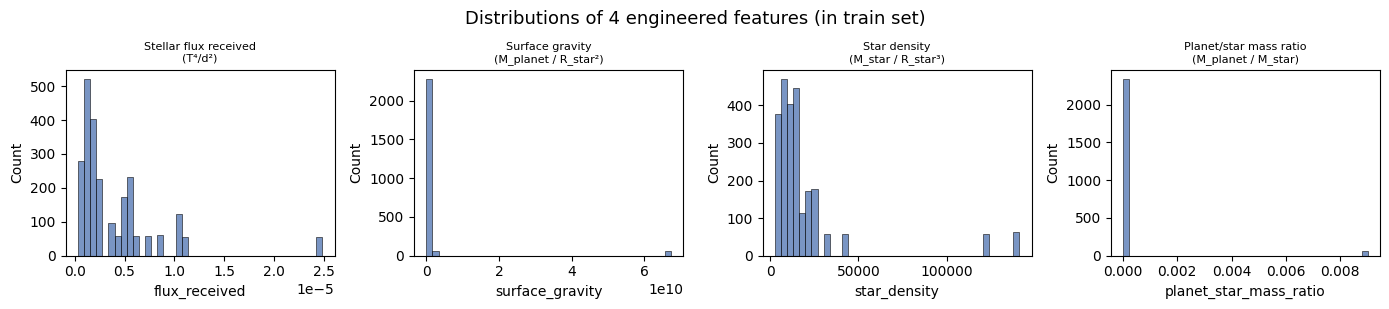

In [15]:
# Distributions of the 4 engineered features (in train set)

engineered_features = [
    ('flux_received',          'Stellar flux received\n(T⁴/d²)'),
    ('surface_gravity',        'Surface gravity\n(M_planet / R_star²)'),
    ('star_density',           'Star density\n(M_star / R_star³)'),
    ('planet_star_mass_ratio', 'Planet/star mass ratio\n(M_planet / M_star)'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (feat, title) in zip(axes, engineered_features):
    sns.histplot(X_aux_train_eng[feat], bins=40, ax=ax, color=sns.color_palette("deep")[0])
    ax.set_title(title, fontsize=8)
fig.suptitle('Distributions of 4 engineered features (in train set)',fontsize=13, y=0.95)
plt.tight_layout()
plt.show()

After calculating those 4 new features I observed that some features spanned many orders of magnitude, so I took the log of the wide-range ones:  
`flux_received` and `surface_gravity` in the engineered features, and `planet_mass_kg`, s`emi_major_axis_m` and `planet_star_mass_ratio` from the reaw features.  
Ineed their distrbibution were right-skewed (concentrated near zero with a long sparse tail). 


| New feature | Formula |
|---|---|
| `log_flux` | $\log(\text{flux\_received})$ |
| `log_gravity` | $\log(\text{surface\_gravity})$ |
| `log_planet_mass` | $\log(\text{planet\_mass\_kg})$ |
| `log_semi_major` | $\log(\text{semi\_major\_axis\_m})$ |
| `log_mass_ratio` | $\log(\text{planet\_star\_mass\_ratio})$ |

In [16]:
# Log additions (5)
# (to handle extreme SI orders of magnitudes) 

def engineer_log_aux_features(df):
    df_eng = df.copy()
    # 5 Logged features
    df_eng['log_flux']       = np.log(df_eng['flux_received'].clip(lower=1e-10))
    df_eng['log_gravity']    = np.log(df_eng['surface_gravity'].clip(lower=1e-10))
    df_eng['log_planet_mass']= np.log(df_eng['planet_mass_kg'].clip(lower=1e-10))
    df_eng['log_semi_major'] = np.log(df_eng['semi_major_axis_m'].clip(lower=1e-10))
    df_eng['log_mass_ratio'] = np.log(df_eng['planet_star_mass_ratio'].clip(lower=1e-10))
    
    return df_eng

# Apply to both _train and _val independently
X_aux_train_eng = engineer_log_aux_features(X_aux_train_eng)
X_aux_val_eng   = engineer_log_aux_features(X_aux_val_eng)


print(f'Auxiliary features: {X_aux.shape[1]} raw → {X_aux_train_eng.shape[1]} engineered')
print('All aux columns:', list(X_aux_train_eng.columns))

Auxiliary features: 5 raw → 14 engineered
All aux columns: ['star_mass_kg', 'star_radius_m', 'star_temperature', 'planet_mass_kg', 'semi_major_axis_m', 'flux_received', 'surface_gravity', 'star_density', 'planet_star_mass_ratio', 'log_flux', 'log_gravity', 'log_planet_mass', 'log_semi_major', 'log_mass_ratio']


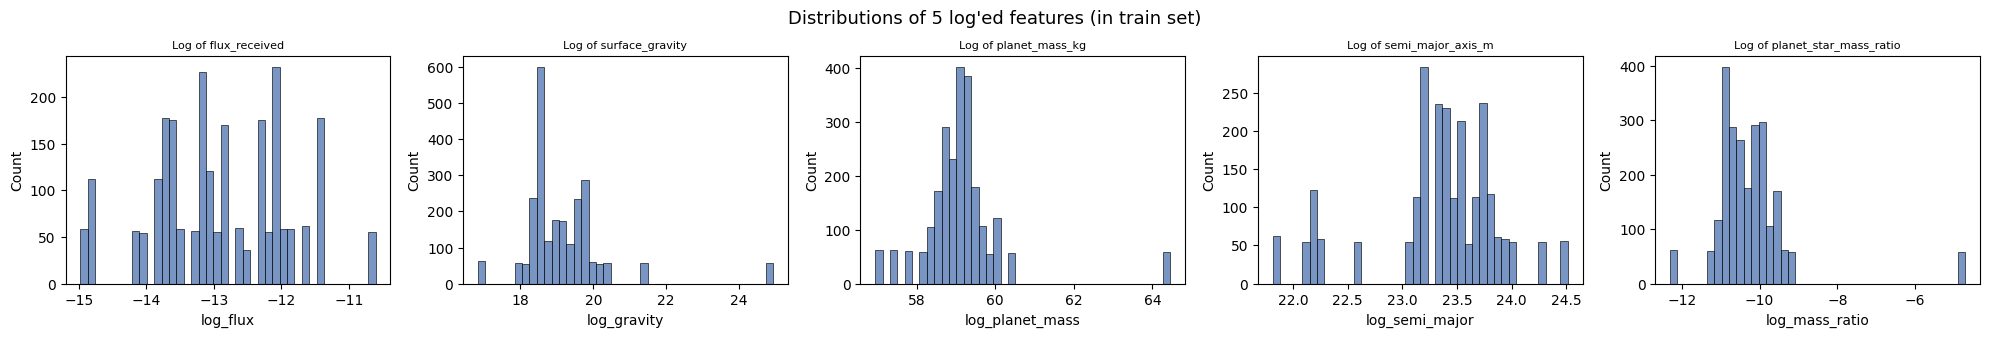

In [17]:
# Distributions of the 5 log'd features (in train set)


logged_features = [
    ('log_flux',          'Log of flux_received'),
    ('log_gravity',        'Log of surface_gravity'),
    ('log_planet_mass',     'Log of planet_mass_kg'),
    ('log_semi_major', 'Log of semi_major_axis_m'),
    ('log_mass_ratio', 'Log of planet_star_mass_ratio')
]

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (feat, title) in zip(axes, logged_features):
    sns.histplot(X_aux_train_eng[feat], bins=40, ax=ax, color=sns.color_palette("deep")[0])
    ax.set_title(title, fontsize=8)
fig.suptitle("Distributions of 5 log'ed features (in train set)",fontsize=13, y=0.95)
plt.tight_layout()
plt.show()

That brings the total of features to  
**5 raw + 4 derived + 5 log'ed = 14 auxiliary features**


Note: the raw features are kept alongside their log() versions : The raw versions preserve absolute magnitude information, the log versions emphasise order-of-magnitude differences. It introduces collinearity, but deep neural networks can handle this and will make the best of both.

### 2.2.B. X_spectra: Spectral Features

`X_spectra` is a 3D array (tensor) that contains the raw satellite spectral measurements for 3000 observations.  
It representing physical light properties recorded per sequence across 52 distinct wavelength ranges.

During exploration, I looked at the distributions of the three spectral channels on the train split to identify where useful signal lies (what info there is in its distribution).

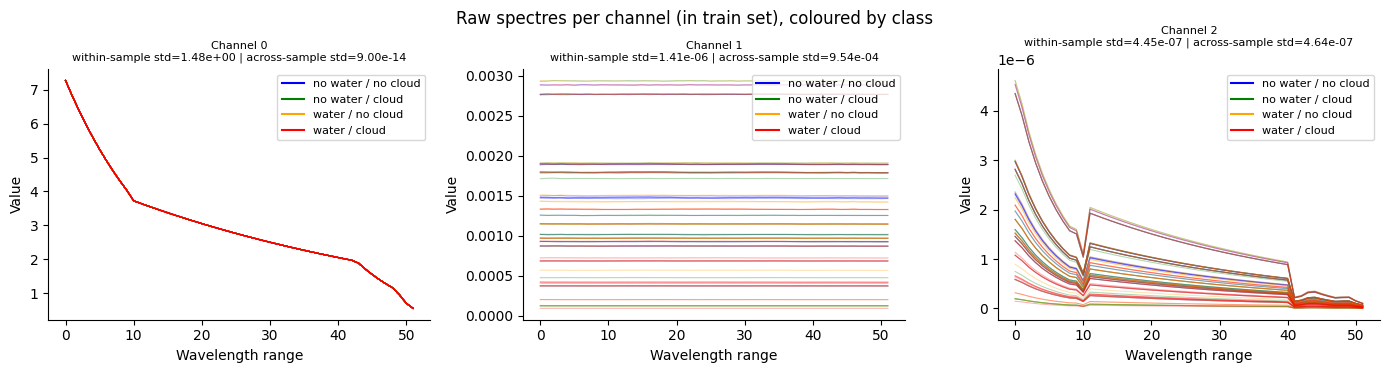

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Define the 4 class combinations
class_defs =[
    (0, 0, 'blue',      'no water / no cloud'),
    (0, 1, 'green', 'no water / cloud'),
    (1, 0, 'orange',      'water / no cloud'),
    (1, 1, 'red',         'water / cloud')
]

for ch in range(3):
    ax = axes[ch]
    # Plot a few sample spectra from each class
    for w, c, color, label in class_defs:
        # Using .values ensures 0-based indexing to align with X_spectra_train
        mask = (y_train['water'].values == w) & (y_train['cloud'].values == c)
        for idx in np.where(mask)[0][:20]:
            ax.plot(X_spectra_train[idx, :, ch], color=color, alpha=0.3, linewidth=0.8)  # transparence to see where data is the same / how it's scattered

    std_within  = X_spectra_train[:, :, ch].std(axis=1).mean()  # avg std within each sample
    std_across  = X_spectra_train[:, :, ch].std(axis=0).mean()  # avg std across samples at each bin
    ax.set_title(
        f'Channel {ch}\nwithin-sample std={std_within:.2e} | across-sample std={std_across:.2e}',
        fontsize=8
    )
    ax.set_xlabel('Wavelength range')
    ax.set_ylabel('Value')
    ax.spines[['top','right']].set_visible(False)

    handles = [plt.Line2D([0], [0], color=c, label=l) for _, _, c, l in class_defs]
    ax.legend(handles=handles, fontsize=8)

plt.suptitle('Raw spectres per channel (in train set), coloured by class', fontsize=12, y=0.92)
plt.tight_layout()
plt.show()

**Observations:** 
These plots reveal that 
- Channel 0 the curve changes across wavelengths but is identical across all samples (across-sample std ≈ 0), carrying no discriminative no class-related signal.
- Channel 1 is a flat line per sample, acting as a scalar amplitude, but the amplitude varies significantly across samples. usable discriminative signal.
- Channel 2 shows variance both within the sample (curve) and across samples (different amplitudes and shapes), but Var(ch2 | class) ≪ Var(ch1 | class) so the network will not be able extract signal from ch2.

**Action:**
I will 
- drop channels 0 and 2, because they contain essentially no across-sample variability or no class-separable structure
- keep Channel 1 as the main raw sequential input
- compute per-sample spectral metrics (std, iqr, kurtosis, n_peaks, depth, correlation) to help the model learn discriminative distributional patterns from Channel 1

In [19]:
# Keep only channel 1 as sequential input
X_spec_train = X_spectra_train[:, :, 1:2].astype(np.float32)   # (2400, 52, 1)
X_spec_val   = X_spectra_val[:,   :, 1:2].astype(np.float32)   # (600,   52, 1)

print("Spectra branch shapes (only ch1):")
print(f"  Train: {X_spec_train.shape}")
print(f"  Val  : {X_spec_val.shape}")

Spectra branch shapes (only ch1):
  Train: (2400, 52, 1)
  Val  : (600, 52, 1)


In [20]:
# I compute the ch1 metrics distributions for each class

def spectral_metrics_ch1(X_spectra):
    """
    X_spectra: (N, 52, 3) original spectra with channels 0,1,2.
    Metrics:
      - std, iqr, kurt, n_peaks, depth from channel 1
      - corr(ch0, ch1) as extra scalar feature
    Returns:
      feats: (N, 6)
      names: list of 6 feature names
    """
    ch1 = X_spectra[:, :, 1]     # (N, 52)
    ch0 = X_spectra[:, :, 0]

    std  = ch1.std(axis=1)
    iqr  = np.percentile(ch1, 75, axis=1) - np.percentile(ch1, 25, axis=1)
    kur  = kurtosis(ch1, axis=1)
    n_peaks = np.array(
        [len(find_peaks(row, height=row.mean())[0]) for row in ch1],
        dtype=np.float32
    )
    depth = (ch1.max(axis=1) - ch1.min(axis=1)) / (np.abs(ch1.max(axis=1)) + 1e-8)
    corr  = np.array(
        [np.corrcoef(ch0[i], ch1[i])[0, 1] for i in range(len(ch1))],
        dtype=np.float32
    )

    feats = np.stack([std, iqr, kur, n_peaks, depth, corr], axis=1).astype(np.float32)
    names = ['ch1_std', 'ch1_iqr', 'ch1_kurt', 'ch1_n_peaks', 'ch1_depth', 'ch_corr']
    return feats, names

X_spectral_tab_train, spectral_feature_names = spectral_metrics_ch1(X_spectra_train)
X_spectral_tab_val,   _                      = spectral_metrics_ch1(X_spectra_val)

print("Spectral tabular features:", spectral_feature_names)
print("X_spectral_tab_train shape:", X_spectral_tab_train.shape)
print("X_spectral_tab_val   shape:", X_spectral_tab_val.shape)

Spectral tabular features: ['ch1_std', 'ch1_iqr', 'ch1_kurt', 'ch1_n_peaks', 'ch1_depth', 'ch_corr']
X_spectral_tab_train shape: (2400, 6)
X_spectral_tab_val   shape: (600, 6)


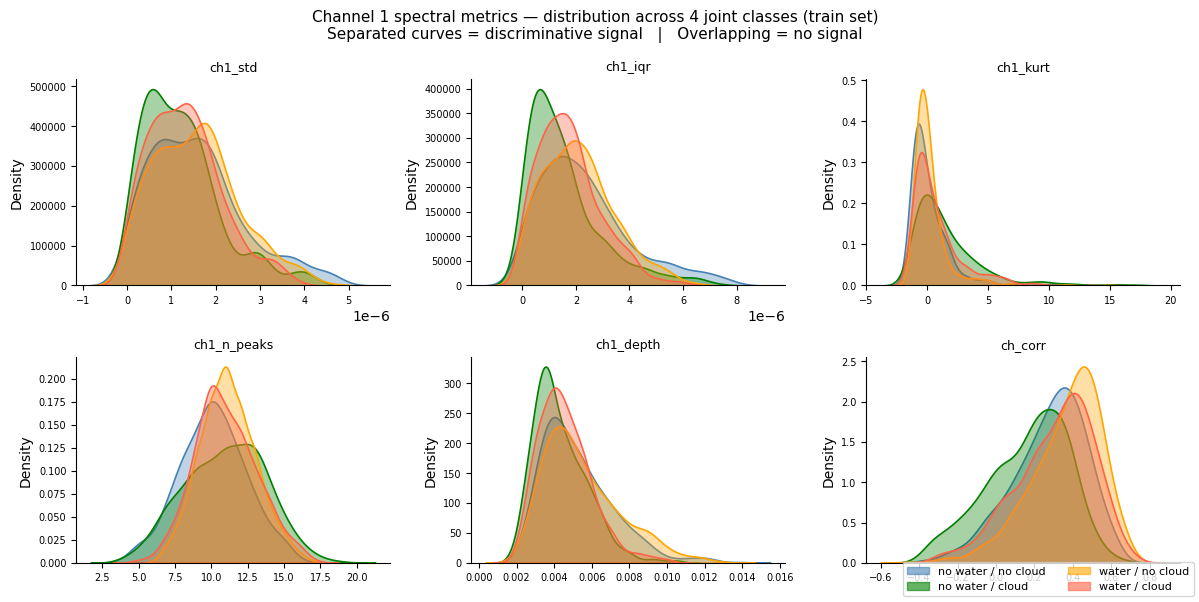

In [21]:
# Plotting the metrics to check wether there is interesting class differences

# joint 4-class label
yw_tr = y_train['water'].values
yc_tr = y_train['cloud'].values
joint = np.array([f'{w}_{c}' for w, c in zip(yw_tr, yc_tr)])

palette4 = {'0_0': 'steelblue', '0_1': 'green', '1_0': 'orange', '1_1': 'tomato'}
labels4  = {'0_0': 'no water / no cloud', '0_1': 'no water / cloud',
            '1_0': 'water / no cloud',    '1_1': 'water / cloud'}

n = X_spectral_tab_train.shape[1]
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
fig.suptitle(
    'Channel 1 spectral metrics — distribution across 4 joint classes (train set)\n'
    'Separated curves = discriminative signal   |   Overlapping = no signal',
    fontsize=11
)

axes = axes.ravel()
for i, name in enumerate(spectral_feature_names):
    ax   = axes[i]
    vals = X_spectral_tab_train[:, i]
    for cls, color in palette4.items():
        data = vals[joint == cls]
        try:
            sns.kdeplot(
                data, ax=ax, fill=True, alpha=0.35, color=color,
                label=labels4[cls], warn_singular=False, linewidth=1.2
            )
        except Exception:
            ax.hist(data, bins=8, alpha=0.35, color=color,
                    label=labels4[cls], density=True)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.6) for c in palette4.values()]
fig.legend(handles, labels4.values(), loc='lower right', fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

After seeing those plots, I do conclude that the metrics are interesting. I kept the computations and concatenate to tabular data from aux table.

In [22]:
# Concatenate the metric to aux splits
aux_train = np.asarray(X_aux_train_eng, dtype=np.float32)
aux_val   = np.asarray(X_aux_val_eng,   dtype=np.float32)

X_total_train = np.concatenate([aux_train, X_spectral_tab_train], axis=1).astype(np.float32)
X_total_val   = np.concatenate([aux_val,   X_spectral_tab_val],   axis=1).astype(np.float32)



## 2.3 Final data Shape & Normalization

The final aux data shapes after preprocessing were (with new engineered features):

In [23]:
print("Total tabular features (aux + spectral metrics):")
print(f"\nTrain shape: {X_total_train.shape}")
print(f"\nVal shape: {X_total_val.shape}")


Total tabular features (aux + spectral metrics):

Train shape: (2400, 20)

Val shape: (600, 20)


The final aux spectral data shapes after preprocessing were (whith channel 0 dropped):

In [24]:
print(f"X_spectra_train_eng shape: {X_spec_train.shape}")
print(f"\nX_spectra_val_eng shape: {X_spec_val.shape}")

X_spectra_train_eng shape: (2400, 52, 1)

X_spectra_val_eng shape: (600, 52, 1)


Finally, I prepare the final inputs for the two branches of the neural network.  

For the tabular branch, I apply standard scaling to the 14 engineered auxiliary features.  

#?For the spectra branch, no normalization is applied per-channel and per-wavelenghts

In [25]:

# Normalize tabular branch (now on X_total_*)

scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_total_train).astype(np.float32)
X_tab_val   = scaler.transform(X_total_val).astype(np.float32)

print("Tabular input to NN (normalized):")
print("  Train:", X_tab_train.shape)
print("  Val  :", X_tab_val.shape)

# Normalize spectral branch (per-channel, now just ch1)
# Per-channel normalization over (samples, wavelengths)
spec_mean = X_spec_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 1)
spec_std  = X_spec_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_spec_train_norm = ((X_spec_train - spec_mean) / spec_std).astype(np.float32)
X_spec_val_norm   = ((X_spec_val   - spec_mean) / spec_std).astype(np.float32)

print("Spectra input to NN (normalized, ch1 only):")
print("  Train:", X_spec_train_norm.shape)
print("  Val  :", X_spec_val_norm.shape)


# Targets stay the same
y_water_train = y_train['water'].values.astype(np.float32)
y_cloud_train = y_train['cloud'].values.astype(np.float32)
y_water_val   = y_val['water'].values.astype(np.float32)
y_cloud_val   = y_val['cloud'].values.astype(np.float32)

Tabular input to NN (normalized):
  Train: (2400, 20)
  Val  : (600, 20)
Spectra input to NN (normalized, ch1 only):
  Train: (2400, 52, 1)
  Val  : (600, 52, 1)


# 3 - Model

In [26]:
# Librairies for part 3

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model


## 3.1 Architecture




### 3.1 Architectures

I use the Keras Functional API for a multi-input, multi-output model. The network processes the two data types separately. Then, it merges them to make final predictions.  

**Architecture Design & Variants**

- **Tabular branch (auxiliary + spectral metrics).**  
  This branch takes all engineered auxiliary features together with the per-sample Channel 1 spectral metrics (std, IQR, kurtosis, number of peaks, depth, and cross-channel correlation).  
  I use a small dense network with Batch Normalization to handle heterogeneous scales and Dropout to limit overfitting.

- **Spectra branch (raw Channel 1).**  
  This branch sees the full `(52, 1)` spectrum from Channel 1 as a short 1-D signal.  
  I compare two ways to process it:  
  * **Variant 1 (Conv1D).** Two stacked Conv1D layers learn local wavelength patterns, followed by GlobalAveragePooling1D to compress the sequence into a fixed-length spectral embedding.  
  * **Variant 2 (Flatten).** A Flatten layer followed by Dense layers treats each wavelength as an independent feature, deliberately ignoring sequence structure to test the value of the convolutional inductive bias.

- **Merge and output heads.**  
  The spectral and tabular embeddings are concatenated into a joint representation, passed through a shared dense layer, and then split into two task-specific heads.  
  Each head ends with a `Dense(1, activation='sigmoid')` unit that outputs the probability of water or cloud presence.

- **Optimization, losses, and metrics.**  
  The model is trained with AdamW (low learning rate and weight decay), use binary cross-entropy for both outputs, and monitor Accuracy and AUC per task; AUC is the main metric — threshold-independent and suited for balanced classes.

In [27]:
# define both variants


def build_model(n_tab_features, variant='conv1d', name='model'):
    # Spectral branch: 1D spectrum from Channel 1, shape (52 time-steps, 1 channel)
    spectra_input = keras.Input(shape=(52, 1), name='spectra_input')

    if variant == 'conv1d':
        # First temporal conv: learn local patterns across neighboring wavelengths
        s = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(spectra_input)
        s = layers.BatchNormalization()(s)  # stabilize activations and gradients

        # Second conv block: deeper spectral features
        s = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(s)
        s = layers.BatchNormalization()(s)

        # Pool over wavelength dimension → fixed-length spectral embedding
        s = layers.GlobalAveragePooling1D()(s)

    elif variant == 'flatten':
        # Baseline: ignore sequential structure and treat wavelengths as independent features
        s = layers.Flatten()(spectra_input)
        s = layers.BatchNormalization()(s)
        s = layers.Dense(64, activation='relu')(s)   # dense projection in spectral space
        s = layers.BatchNormalization()(s)
        s = layers.Dense(64, activation='relu')(s)
    else:
        raise ValueError("variant must be 'conv1d' or 'flatten'")

    # Final spectral representation
    spectra_feat = layers.Dense(32, activation='relu')(s)

    # Tabular branch: auxiliary physics + ch1 summary metrics
    tabular_input = keras.Input(shape=(n_tab_features,), name='tabular_input')
    t = layers.Dense(128, activation='relu')(tabular_input)   # wide first layer for rich interactions
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.3)(t)                               # regularization
    t = layers.Dense(64, activation='relu')(t)               # second non-linear block
    t = layers.BatchNormalization()(t)
    tabular_feat = layers.Dense(32, activation='relu')(t)    # compact tabular embedding

    # Merge both modalities
    merged = layers.Concatenate(name='merge')([spectra_feat, tabular_feat])
    merged = layers.Dense(64, activation='relu')(merged)     # joint representation
    merged = layers.Dropout(0.3)(merged)

    # Task-specific heads
    water_head = layers.Dense(16, activation='relu')(merged)
    cloud_head = layers.Dense(16, activation='relu')(merged)

    water_out = layers.Dense(1, activation='sigmoid', name='water')(water_head)
    cloud_out = layers.Dense(1, activation='sigmoid', name='cloud')(cloud_head)

    model = Model(inputs=[spectra_input, tabular_input],
                  outputs=[water_out, cloud_out],
                  name=name)

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
        loss={'water': 'binary_crossentropy', 'cloud': 'binary_crossentropy'},
        loss_weights={'water': 1.0, 'cloud': 1.0},
        metrics={
            'water': ['accuracy', keras.metrics.AUC(name='auc')],
            'cloud': ['accuracy', keras.metrics.AUC(name='auc')],
        },
    )
    return model

n_tab = X_tab_train.shape[1]
model_v1 = build_model(n_tab, variant='conv1d',  name='v1_conv1d')
model_v2 = build_model(n_tab, variant='flatten', name='v2_flatten')

### 3.2 Training

I use Early Stopping to prevent overfitting and save training time. It monitors the total validation loss. It stops training when the loss stops improving for *15* epochs. It restores the best weights automatically. I train for a maximum of *150* epochs with a batch size of *64*.


I fit both models on the training split. I validate on the validation split.

In [ ]:
train_inputs = {'spectra_input': X_spec_train_norm, 'tabular_input': X_tab_train}
val_inputs   = {'spectra_input': X_spec_val_norm,   'tabular_input': X_tab_val}
train_targets = {'water': y_water_train, 'cloud': y_cloud_train}
val_targets   = {'water': y_water_val,   'cloud': y_cloud_val}

cb = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                    restore_best_weights=True)]
epochs = 150
batch_size = 64

print("Training Variant 1 (Conv1D)")
history_v1 = model_v1.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=1
)

print("Training Variant 2 (Flatten)")
history_v2 = model_v2.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=1
)



I plot the learning curves of both variants.

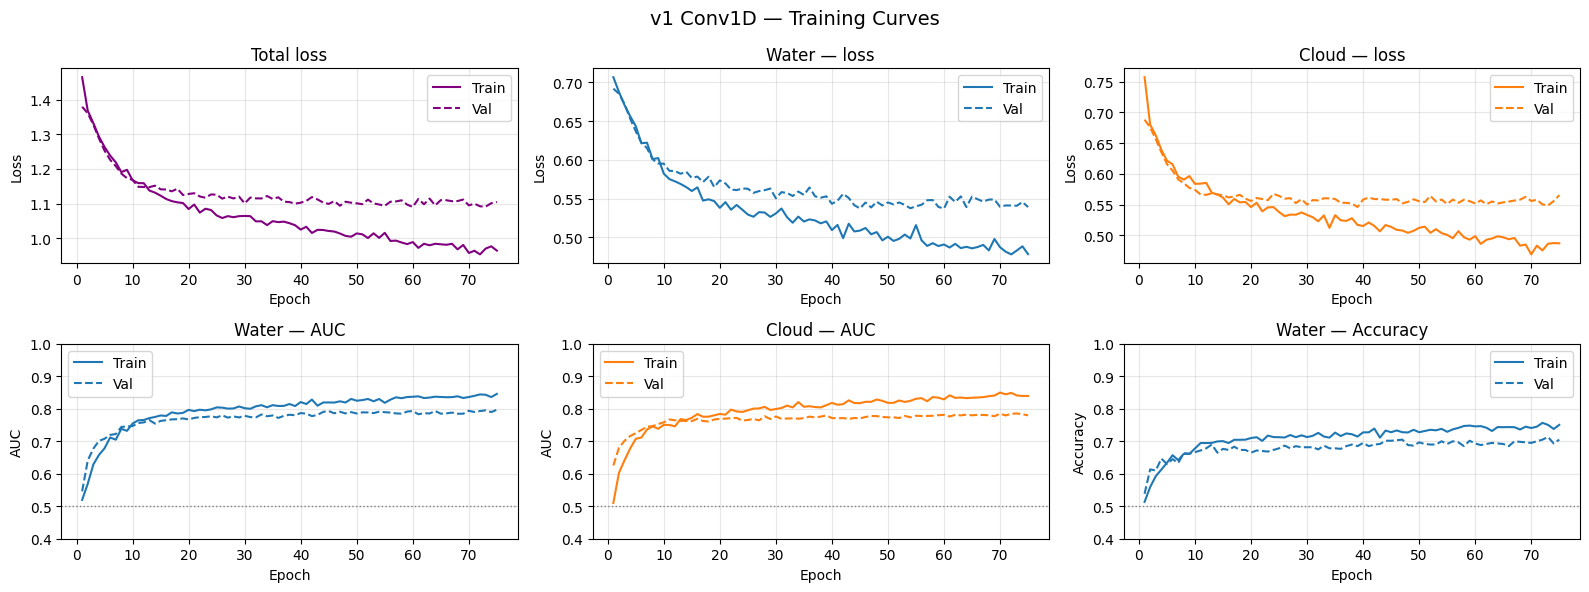

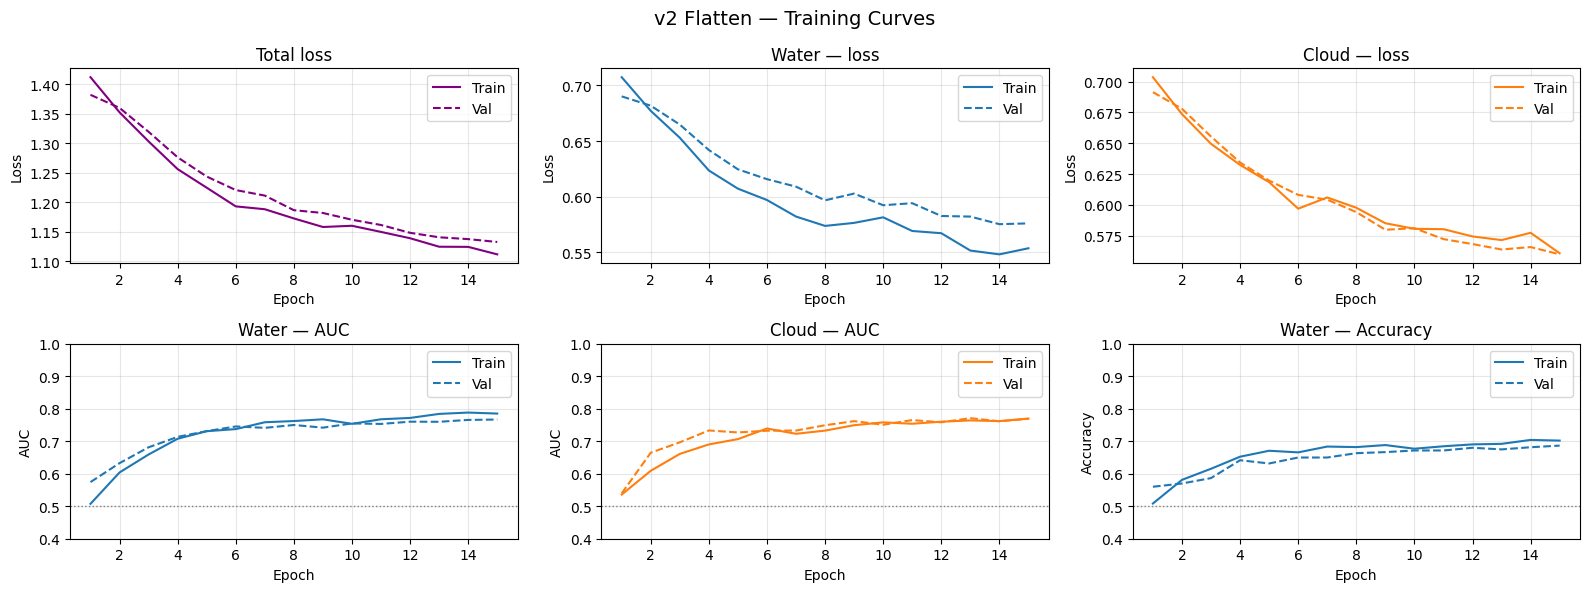

In [29]:
def plot_learning_curves(history, title_prefix='v1 Baseline'):
    h = history.history
    epochs = np.arange(1, len(h['loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(16, 6))
    fig.suptitle(f'{title_prefix} — Training Curves', fontsize=14)

    # Total loss
    ax = axes[0, 0]
    ax.plot(epochs, h['loss'], label='Train', color='purple')
    ax.plot(epochs, h['val_loss'], label='Val', color='purple', linestyle='--')
    ax.set_title('Total loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Water loss
    ax = axes[0, 1]
    ax.plot(epochs, h['water_loss'], label='Train', color='tab:blue')
    ax.plot(epochs, h['val_water_loss'], label='Val', color='tab:blue', linestyle='--')
    ax.set_title('Water — loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Cloud loss
    ax = axes[0, 2]
    ax.plot(epochs, h['cloud_loss'], label='Train', color='tab:orange')
    ax.plot(epochs, h['val_cloud_loss'], label='Val', color='tab:orange', linestyle='--')
    ax.set_title('Cloud — loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Water AUC
    ax = axes[1, 0]
    ax.plot(epochs, h['water_auc'], label='Train', color='tab:blue')
    ax.plot(epochs, h['val_water_auc'], label='Val', color='tab:blue', linestyle='--')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(0.4, 1.0)
    ax.set_title('Water — AUC'); ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Cloud AUC
    ax = axes[1, 1]
    ax.plot(epochs, h['cloud_auc'], label='Train', color='tab:orange')
    ax.plot(epochs, h['val_cloud_auc'], label='Val', color='tab:orange', linestyle='--')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(0.4, 1.0)
    ax.set_title('Cloud — AUC'); ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Water Accuracy
    ax = axes[1, 2]
    ax.plot(epochs, h['water_accuracy'], label='Train', color='tab:blue')
    ax.plot(epochs, h['val_water_accuracy'], label='Val', color='tab:blue', linestyle='--')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(0.4, 1.0)
    ax.set_title('Water — Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_v1, title_prefix='v1 Conv1D')
plot_learning_curves(history_v2, title_prefix='v2 Flatten')

### 3.3 Model Evaluation

I evaluate both variants on the validation split and extract the accuracy and AUC metrics for a side-by-side comparison.


In [30]:
def print_eval(model):
    # return_dict=True natively returns a dictionary of metric names mapped to their values
    metrics = model.evaluate(val_inputs, val_targets, verbose=0, return_dict=True)
    
    try:
        w_acc =[v for k, v in metrics.items() if 'water' in k.lower() and 'acc' in k.lower()][0]
        w_auc =[v for k, v in metrics.items() if 'water' in k.lower() and 'auc' in k.lower()][0]
        c_acc =[v for k, v in metrics.items() if 'cloud' in k.lower() and 'acc' in k.lower()][0]
        c_auc =[v for k, v in metrics.items() if 'cloud' in k.lower() and 'auc' in k.lower()][0]
        
        print(f"--- {model.name} ---")
        print(f"Water: Acc = {w_acc:.4f} | AUC = {w_auc:.4f}")
        print(f"Cloud: Acc = {c_acc:.4f} | AUC = {c_auc:.4f}")
        print(f"Mean AUC: {(w_auc + c_auc) / 2:.4f}\n")
        
    except IndexError:
        # Fallback if Keras naming conventions change
        print(f"--- {model.name} ---")
        print(f"Raw metrics: {metrics}\n")

print_eval(model_v1)
print_eval(model_v2)

--- v1_conv1d ---
Water: Acc = 0.6933 | AUC = 0.7931
Cloud: Acc = 0.7033 | AUC = 0.7814
Mean AUC: 0.7873

--- v2_flatten ---
Water: Acc = 0.5600 | AUC = 0.5743
Cloud: Acc = 0.5217 | AUC = 0.5397
Mean AUC: 0.5570



v1 Conv1D: {'cloud_accuracy': 0.70333331823349, 'cloud_auc': 0.7814055681228638, 'cloud_loss': 0.5552968978881836, 'loss': 1.0903913974761963, 'water_accuracy': 0.6933333277702332, 'water_auc': 0.7931222915649414, 'water_loss': 0.5347680449485779}
v2 Flatten: {'cloud_accuracy': 0.5216666460037231, 'cloud_auc': 0.5396833419799805, 'cloud_loss': 0.6915913820266724, 'loss': 1.3817334175109863, 'water_accuracy': 0.5600000023841858, 'water_auc': 0.5743444561958313, 'water_loss': 0.6900902986526489}


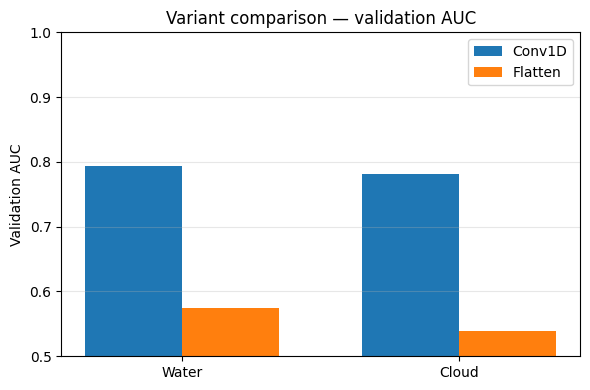

In [31]:
def get_eval_dict(model):
    return model.evaluate(val_inputs, val_targets, verbose=0, return_dict=True)

metrics_v1 = get_eval_dict(model_v1)
metrics_v2 = get_eval_dict(model_v2)

print('v1 Conv1D:', metrics_v1)
print('v2 Flatten:', metrics_v2)

# Extract AUCs
water_auc_v1 = metrics_v1['water_auc']
cloud_auc_v1 = metrics_v1['cloud_auc']
water_auc_v2 = metrics_v2['water_auc']
cloud_auc_v2 = metrics_v2['cloud_auc']

labels = ['Water', 'Cloud']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, [water_auc_v1, cloud_auc_v1], width, label='Conv1D')
ax.bar(x + width/2, [water_auc_v2, cloud_auc_v2], width, label='Flatten')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Validation AUC')
ax.set_title('Variant comparison — validation AUC')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Final choice justification

I compare two architectures that differ only in how they process the Channel 1 spectrum:  
a Conv1D branch that treats it as a short sequence,  
and a Flatten branch that treats each wavelength as an independent feature.  
On the validation set, the Conv1D model reaches **AUC ≈ 0.78 (water) and 0.77 (cloud)**, while the Flatten model is close to random with **AUC ≈ 0.58** for both tasks;  
accuracies follow the same pattern (≈0.69 vs ≈0.56).

This gap shows that explicitly modelling local wavelength structure with Conv1D + GlobalAveragePooling1D is crucial:  
the convolutional filters can exploit smooth spectral patterns and small relative differences across wavelengths,  
whereas the Flatten baseline discards this inductive bias and overfits noise. I therefore selected **Variant 1 (Conv1D)** as the final architecture,  
with a mean validation AUC of ~0.78 as the main performance indicator.

# Conclusion

In summary, I built a full multi-input, multi-output model using the Keras Functional API, which fits the structure of this problem:  
one branch processes the spectra, one branch processes the auxiliary features, and both are merged before producing two separate predictions (water, cloud).  
I defined clear preprocessing steps, designed and justified the architecture, compared two reasonable variants, and selected the best one based on validation AUC.  